In [2]:
using LorenzParameterEstimation
using Plots, Random, Statistics, LinearAlgebra
using StatsBase, PlotlyJS, Revise, Profile, ProfileView, ProfileCanvas, Optimisers

In [3]:
"""
    plot_param_history(res, base_params; title_prefix="Parameter")

Visualize how each Lorenz-63 parameter evolved during training.
`res` is the NamedTuple returned by `train_statistics` (needs a `param_history` field),
and `base_params` is an `L63Parameters` instance for the reference line.
"""
function plot_param_history(res, base_params::L63Parameters; title_prefix="Parameter")
    hasproperty(res, :param_history) ||
        error("`res` must contain a `param_history` field")

    history = res.param_history
    isempty(history) && error("`res.param_history` is empty")

    params_syms = (:σ, :ρ, :β, :x_s, :y_s, :z_s, :θ)
    epochs = 1:length(history)

    plt = plot(layout=(4, 2), size=(950, 850))
    for (idx, sym) in enumerate(params_syms)
        values = [getfield(p, sym) for p in history]

        plot!(plt[idx], epochs, values;
              label = idx == 1 ? "estimate" : "",
              marker = :circle, ms = 3, lw = 2,
              xlabel = "epoch",
              ylabel = string(sym),
              title = "$(title_prefix) $(string(sym))")

        hline!(plt[idx], [getfield(base_params, sym)];
               label = idx == 1 ? "base" : "",
               ls = :dash, color = :gray)
    end

    plt
end

plot_param_history

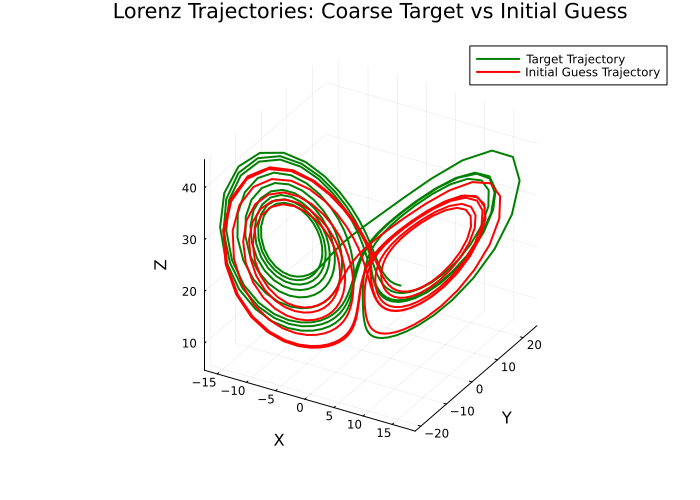

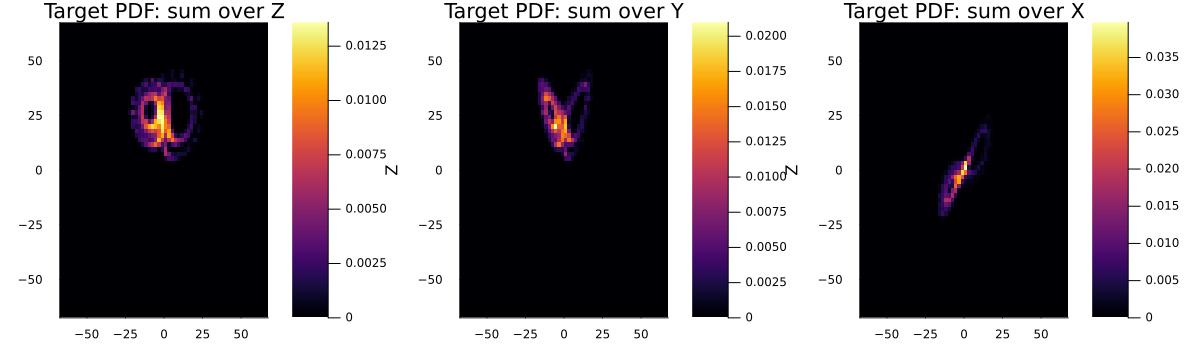

"# Train (update only ρ). Key tweaks: smaller LR, less frequent resampling, tighter clip.\nProfile.@profile begin\n    res_test = train_statistics(\n        init_params;\n        target = target_pdf,\n        stats = (:pdf3d,),\n        optimizer = Optimisers.Adam(1e-3),\n      " ⋯ 221 bytes ⋯ "    rel_delta = 1e-5,\n        cfg = cfg_test,\n        verbose = true,\n        gradient_verbose = false,\n        gradient_clip_norm = 5.0,\n    )\nend\n\n\nPlots.plot(res_test.loss_history; xlabel=\"Epoch\", ylabel=\"PDF Loss\",\n           title=\"PDF Training Loss\", legend=false)"

In [4]:
using Optimisers, Random, Plots

params_classic = classic_params()
init_params = L63Parameters(σ=10.0, ρ=25.0, β=8/3)

T_coarse   = 10.0
M_coarse   = 400
u0_coarse  = Float64[1, 1, 25]
dt_coarse  = T_coarse / M_coarse
tspan_coarse = (0.0, T_coarse)

# Target trajectory (classic Lorenz)
base_params_test = classic_params()
trajectory_target = integrate(base_params_test, u0_coarse, tspan_coarse, dt_coarse)
trajectory_guess  = integrate(init_params,       u0_coarse, tspan_coarse, dt_coarse)

# Build target PDF on a moderate grid and KEEP the same h for training
xs = trajectory_target.u[:, 1]; ys = trajectory_target.u[:, 2]; zs = trajectory_target.u[:, 3]

nbins = 64  # 64 is heavy; 16–32 is fine to start
xs = trajectory_target.u[:,1]; ys = trajectory_target.u[:,2]; zs = trajectory_target.u[:,3]
hw = maximum(abs, vcat(xs, ys, zs)) * 1.50

pdf_cfg = make_pdf_config(Float64; nbins=nbins, range_halfwidth=hw, loss_mode=:kl)
centers = pdf_cfg.centers
Δ = (centers[end]-centers[1])/(length(centers)-1)
h = 0.5*Δ 
pdf_cfg = make_pdf_config(Float64; nbins=nbins, range_halfwidth=hw, loss_mode=:kl, bandwidth=h)


p3d = zeros(Float64, nbins^3)
R = max(1, ceil(Int, 3h/Δ))
soft_hist_3d_local(xs, ys, zs, centers, h, p3d; R=R)
p3d ./= sum(p3d)
target_pdf = (centers = centers, p3d = p3d)

# Multiple ICs near [1,1,25]
rng_test = MersenneTwister(42)
B_test   = 20
ics_test = [[1.0, 1.0, 25.0] .+ 0.20 .* randn(rng_test, 3) for _ in 1:B_test]
U0_test  = hcat(ics_test...)

# Constant-bandwidth schedule that EXACTLY matches pdf_cfg.h
sched = PdfSchedule{Float64}(h/Δ, h/Δ, 1.0)  # fixed bandwidth = h


cfg_test = ClimateConfig(
    dt = dt_coarse,
    steps = M_coarse * 3,
    samples_per_epoch = round(Int, 0.5*M_coarse),
    initial_conditions = U0_test,
    pdf = pdf_cfg,          # has bandwidth=h
    schedule = sched,       # forces h_curr == h
    rng = MersenneTwister(42),
    batch_size = 2
    
)

# Plot (optional)
plt_traj = Plots.plot(
    trajectory_target.u[:,1], trajectory_target.u[:,2], trajectory_target.u[:,3];
    label="Target Trajectory", linecolor=:green, linewidth=2, seriestype=:path3d
)
Plots.plot!(
    plt_traj, trajectory_guess.u[:,1], trajectory_guess.u[:,2], trajectory_guess.u[:,3];
    label="Initial Guess Trajectory", linecolor=:red, linewidth=2, seriestype=:path3d
)
Plots.plot!(plt_traj; title="Lorenz Trajectories: Coarse Target vs Initial Guess",
    xlabel="X", ylabel="Y", zlabel="Z", legend=:topright, size=(700, 500)
)
display(plt_traj)

# Sum along each axis to get 2D marginals
m = length(centers)          # == nbins
P = reshape(p3d, m, m, m)    # (64,64,64) now
marg_xy = sum(P, dims=3)[:, :, 1]  # sum over z
marg_xz = sum(P, dims=2)[:, 1, :]  # sum over y
marg_yz = sum(P, dims=1)[1, :, :]  # sum over x

# Plot the 2D marginals
plt_xy = Plots.heatmap(centers, centers, marg_xy; xlabel="X", ylabel="Y", title="Target PDF: sum over Z")
plt_xz = Plots.heatmap(centers, centers, marg_xz; xlabel="X", ylabel="Z", title="Target PDF: sum over Y")
plt_yz = Plots.heatmap(centers, centers, marg_yz; xlabel="Y", ylabel="Z", title="Target PDF: sum over X")
plt_marginals = Plots.plot(plt_xy, plt_xz, plt_yz; layout=(1,3), size=(1200,350))

display(plt_marginals)

"""
# Train (update only ρ). Key tweaks: smaller LR, less frequent resampling, tighter clip.
Profile.@profile begin
    res_test = train_statistics(
        init_params;
        target = target_pdf,
        stats = (:pdf3d,),
        optimizer = Optimisers.Adam(1e-3),
        update_mask = (σ=false, ρ=true, β=false, x_s=false, y_s=false, z_s=false, θ=false),
        epochs = 10_000,
        refresh = 5,
        early_stopping_patience = 1500,
        early_stopping_min_delta = 1e-6,
        rel_delta = 1e-5,
        cfg = cfg_test,
        verbose = true,
        gradient_verbose = false,
        gradient_clip_norm = 5.0,
    )
end


Plots.plot(res_test.loss_history; xlabel="Epoch", ylabel="PDF Loss",
           title="PDF Training Loss", legend=false)"""

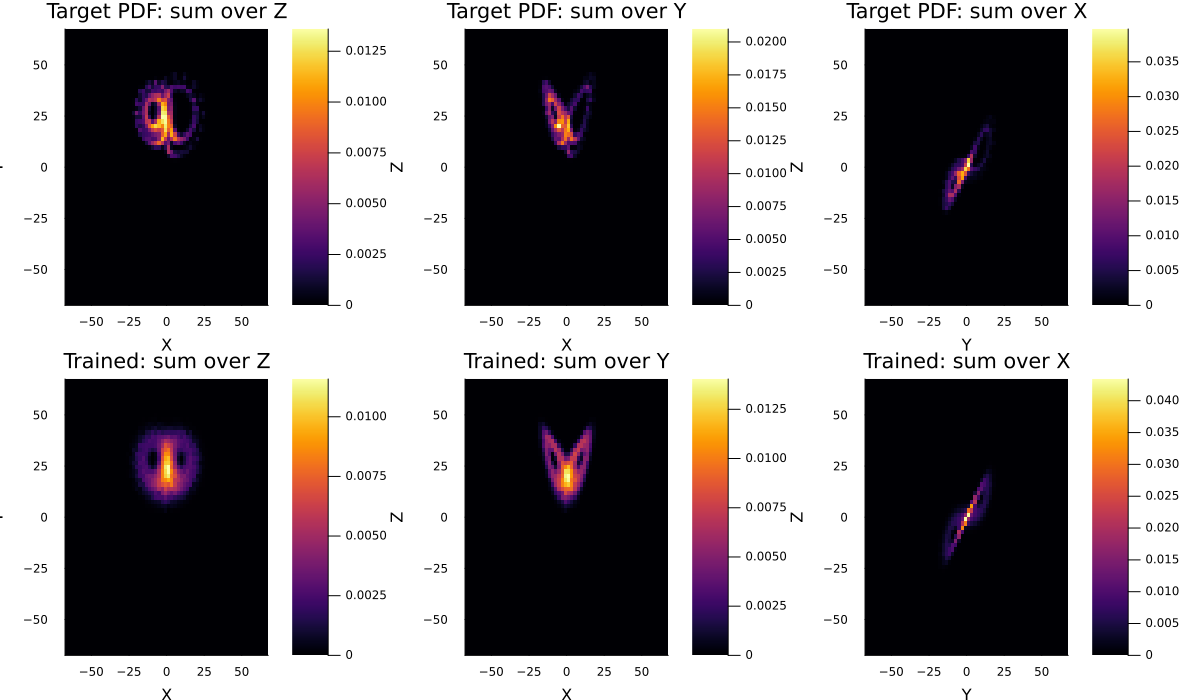

UndefVarError: UndefVarError: `plot_param_history` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [5]:
recovered_pdf = res_test.final_statistics[:pdf3d]
m = length(recovered_pdf.centers)
pdf = reshape(recovered_pdf.p3d, m, m, m)

# Sum along each axis to get 2D marginals for recovered PDF
marg_xy_rec = sum(pdf, dims=3)[:, :, 1]  # sum over z
marg_xz_rec = sum(pdf, dims=2)[:, 1, :]  # sum over y
marg_yz_rec = sum(pdf, dims=1)[1, :, :]  # sum over x

plt_xy_rec = Plots.heatmap(recovered_pdf.centers, recovered_pdf.centers, marg_xy_rec; xlabel="X", ylabel="Y", title="Trained: sum over Z")
plt_xz_rec = Plots.heatmap(recovered_pdf.centers, recovered_pdf.centers, marg_xz_rec; xlabel="X", ylabel="Z", title="Trained: sum over Y")
plt_yz_rec = Plots.heatmap(recovered_pdf.centers, recovered_pdf.centers, marg_yz_rec; xlabel="Y", ylabel="Z", title="Trained: sum over X")
plt_marginals_rec = Plots.plot(plt_xy_rec, plt_xz_rec, plt_yz_rec; layout=(1,3), size=(1200,350))

# Initial PDF marginals (already computed aboe)
plt_marginals_init = plt_marginals

# Stack initial and recovered marginals vertically
plt_compare = Plots.plot(plt_marginals_init, plt_marginals_rec; layout=(2,1), size=(1200,700))
display(plt_compare)

plot_params = plot_param_history(res_test, base_params_test)
display(plot_params)

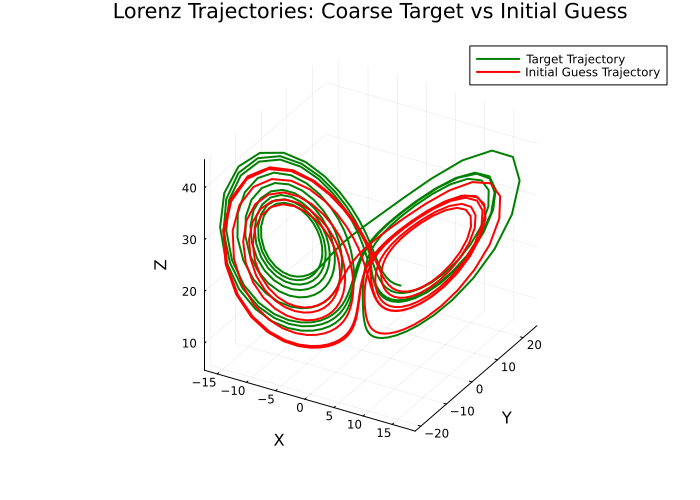

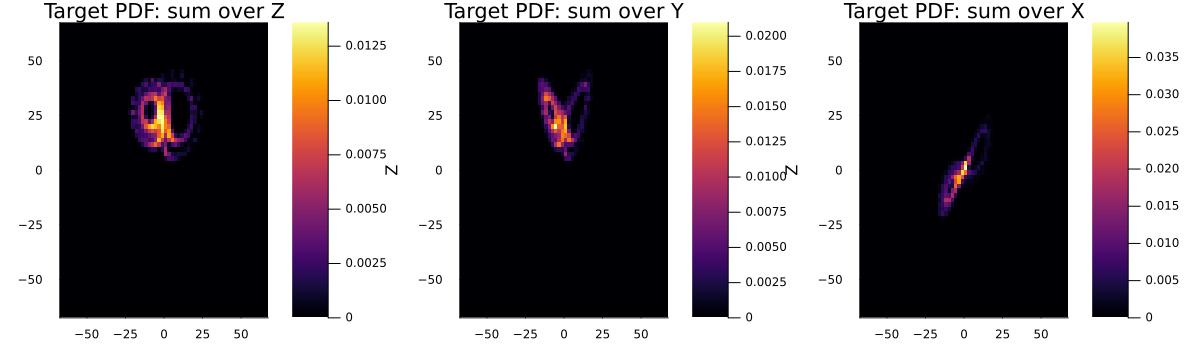

UnifiedTrain | PDF3D loss=kl | dt=0.025 steps=1200 | ICs=256 | k=200 | bins=64^3
Init  | σ=10.000000 ρ=25.000000 β=2.666667 x_s=0.000000 y_s=0.000000 z_s=0.000000 θ=1.000000
  Gradients clipped (norm 2.078e+09 > 5.00)
Epoch    1 | σ=10.000000 (Δ0.00e+00)  ρ=25.001000 (Δ1.00e-03)  β=2.666667 (Δ0.00e+00)  | loss=1.082466e+00 | g_norm=5.000e+00
  Gradients clipped (norm 9.706e+08 > 5.00)
Epoch    5 | σ=10.000000 (Δ0.00e+00)  ρ=25.004512 (Δ5.12e-04)  β=2.666667 (Δ0.00e+00)  | loss=1.087567e+00 | g_norm=5.000e+00
  Gradients clipped (norm 1.415e+09 > 5.00)
Epoch   10 | σ=10.000000 (Δ0.00e+00)  ρ=25.006978 (Δ5.95e-04)  β=2.666667 (Δ0.00e+00)  | loss=1.087895e+00 | g_norm=5.000e+00


InterruptException: InterruptException:

In [ ]:
params_classic = classic_params()
init_params = L63Parameters(σ=10.0, ρ=25.0, β=8/3)

T_coarse   = 10.0
M_coarse   = 400
u0_coarse  = Float64[1, 1, 25]
dt_coarse  = T_coarse / M_coarse
tspan_coarse = (0.0, T_coarse)

# Target trajectory (classic Lorenz)
base_params_test = classic_params()
trajectory_target = integrate(base_params_test, u0_coarse, tspan_coarse, dt_coarse)
trajectory_guess  = integrate(init_params,       u0_coarse, tspan_coarse, dt_coarse)

nbins = 64  # 64 is heavy; 16–32 is fine to start
xs = trajectory_target.u[:,1]; ys = trajectory_target.u[:,2]; zs = trajectory_target.u[:,3]
hw = maximum(abs, vcat(xs, ys, zs)) * 1.50

centers = pdf_cfg.centers
Δ = (centers[end]-centers[1])/(length(centers)-1)
h = 0.5*Δ 
pdf_cfg = make_pdf_config(Float64; nbins=nbins, range_halfwidth=hw, loss_mode=:kl, bandwidth=h)


p3d = zeros(Float64, nbins^3)
R = max(1, ceil(Int, 3h/Δ))
soft_hist_3d_local(xs, ys, zs, centers, h, p3d; R=R)
p3d ./= sum(p3d)
target_pdf = (centers = centers, p3d = p3d)

# Multiple ICs near [1,1,25]
rng_test = MersenneTwister(42)
B_test   = 256
ics_test = [[1.0, 1.0, 25.0] .+ 0.20 .* randn(rng_test, 3) for _ in 1:B_test]
U0_test  = hcat(ics_test...)

# Constant-bandwidth schedule that EXACTLY matches pdf_cfg.h
sched = PdfSchedule{Float64}(h/Δ, h/Δ, 1.0)  # fixed bandwidth = h

cfg_test = ClimateConfig(
    dt = dt_coarse,
    steps = M_coarse * 3,
    samples_per_epoch = round(Int, 0.5*M_coarse),
    initial_conditions = U0_test,
    pdf = pdf_cfg,          # has bandwidth=h
    schedule = sched,       # forces h_curr == h
    rng = MersenneTwister(42),
    batch_size = 16,               # <—— batching ON
)

# Plot (optional)
plt_traj = Plots.plot(
    trajectory_target.u[:,1], trajectory_target.u[:,2], trajectory_target.u[:,3];
    label="Target Trajectory", linecolor=:green, linewidth=2, seriestype=:path3d
)
Plots.plot!(
    plt_traj, trajectory_guess.u[:,1], trajectory_guess.u[:,2], trajectory_guess.u[:,3];
    label="Initial Guess Trajectory", linecolor=:red, linewidth=2, seriestype=:path3d
)
Plots.plot!(plt_traj; title="Lorenz Trajectories: Coarse Target vs Initial Guess",
    xlabel="X", ylabel="Y", zlabel="Z", legend=:topright, size=(700, 500)
)
display(plt_traj)

# Sum along each axis to get 2D marginals
m = length(centers)          # == nbins
P = reshape(p3d, m, m, m)    # (64,64,64) now
marg_xy = sum(P, dims=3)[:, :, 1]  # sum over z
marg_xz = sum(P, dims=2)[:, 1, :]  # sum over y
marg_yz = sum(P, dims=1)[1, :, :]  # sum over x

# Plot the 2D marginals
plt_xy = Plots.heatmap(centers, centers, marg_xy; xlabel="X", ylabel="Y", title="Target PDF: sum over Z")
plt_xz = Plots.heatmap(centers, centers, marg_xz; xlabel="X", ylabel="Z", title="Target PDF: sum over Y")
plt_yz = Plots.heatmap(centers, centers, marg_yz; xlabel="Y", ylabel="Z", title="Target PDF: sum over X")
plt_marginals = Plots.plot(plt_xy, plt_xz, plt_yz; layout=(1,3), size=(1200,350))

display(plt_marginals)

# Train (update only ρ). Key tweaks: smaller LR, less frequent resampling, tighter clip.
Profile.@profile begin
    res_test = train_statistics(
        init_params;
        target = target_pdf,
        stats = (:pdf3d,),
        optimizer = Optimisers.Adam(1e-3),
        update_mask = (σ=false, ρ=true, β=false, x_s=false, y_s=false, z_s=false, θ=false),
        epochs = 10_000,
        refresh = 5,
        early_stopping_patience = 1500,
        early_stopping_min_delta = 1e-6,
        rel_delta = 1e-5,
        cfg = cfg_test,
        verbose = true,
        gradient_verbose = false,
        gradient_clip_norm = 5.0,
    )
end

println("""
Parameter recovery summary:
  Initial guess:      $(init_params)
  Recovered params:   $(res_test.params)
  Target (goal):      $(base_params_test)
""")

Plots.plot(res_test.loss_history; xlabel="Epoch", ylabel="PDF Loss",
           title="PDF Training Loss", legend=false)

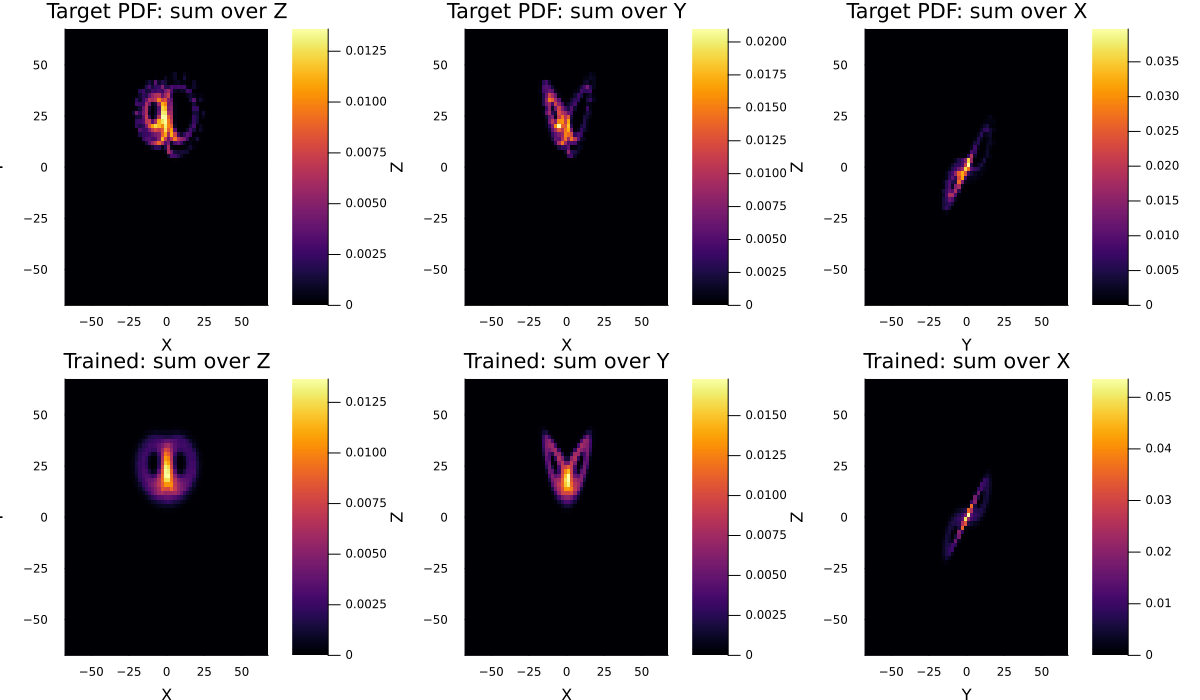

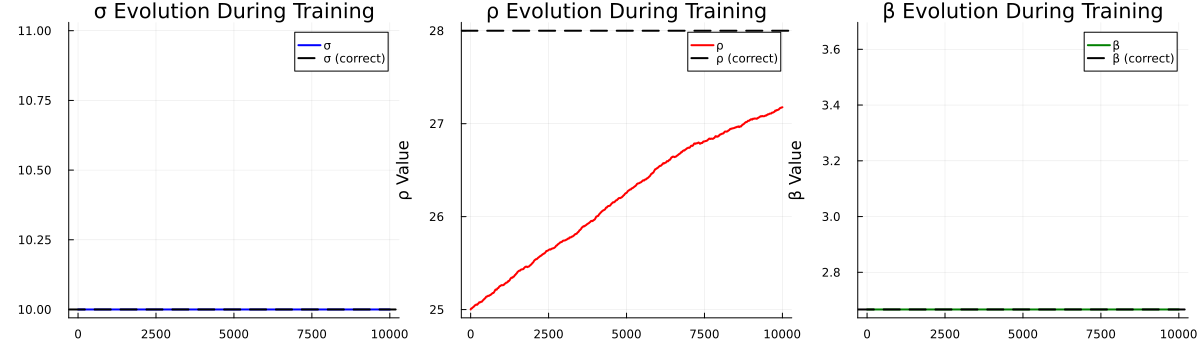

In [6]:
recovered_pdf = res_test.final_statistics[:pdf3d]
m = length(recovered_pdf.centers)
pdf = reshape(recovered_pdf.p3d, m, m, m)

# Sum along each axis to get 2D marginals for recovered PDF
marg_xy_rec = sum(pdf, dims=3)[:, :, 1]  # sum over z
marg_xz_rec = sum(pdf, dims=2)[:, 1, :]  # sum over y
marg_yz_rec = sum(pdf, dims=1)[1, :, :]  # sum over x

plt_xy_rec = Plots.heatmap(recovered_pdf.centers, recovered_pdf.centers, marg_xy_rec; xlabel="X", ylabel="Y", title="Trained: sum over Z")
plt_xz_rec = Plots.heatmap(recovered_pdf.centers, recovered_pdf.centers, marg_xz_rec; xlabel="X", ylabel="Z", title="Trained: sum over Y")
plt_yz_rec = Plots.heatmap(recovered_pdf.centers, recovered_pdf.centers, marg_yz_rec; xlabel="Y", ylabel="Z", title="Trained: sum over X")
plt_marginals_rec = Plots.plot(plt_xy_rec, plt_xz_rec, plt_yz_rec; layout=(1,3), size=(1200,350))

# Initial PDF marginals (already computed aboe)
plt_marginals_init = plt_marginals

# Stack initial and recovered marginals vertically
plt_compare = Plots.plot(plt_marginals_init, plt_marginals_rec; layout=(2,1), size=(1200,700))
display(plt_compare)

plot_params = plot_param_history(res_test, base_params_test)
display(plot_params)

# Optimising gradients

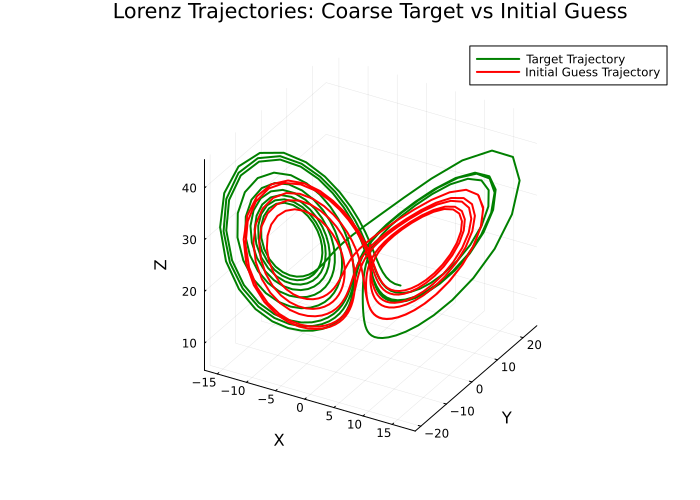

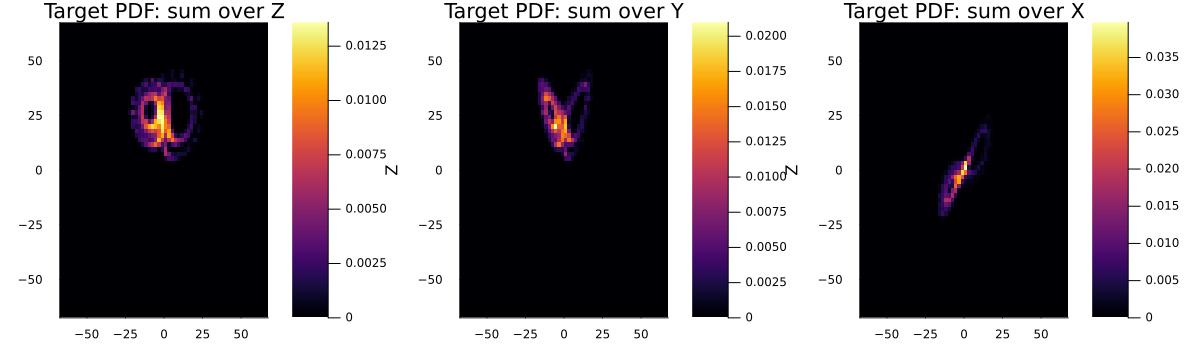

Parameter recovery summary:
  Initial guess:      L63Parameters{Float64}(9.0, 25.0, 2.0, 0.0, 0.0, 0.0, 1.0)
  Recovered params:   L63Parameters{Float64}(8.959995548261128, 25.033687372559914, 1.9773952695361836, 0.0, 0.0, 0.0, 1.0)
  Target (goal):      L63Parameters{Float64}(10.0, 28.0, 2.6666666666666665, 0.0, 0.0, 0.0, 1.0)



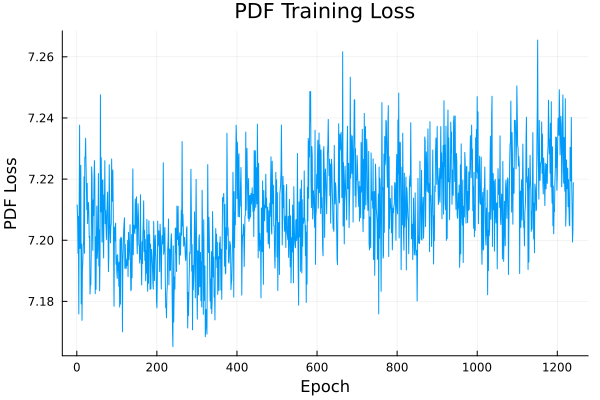

In [13]:
using Optimisers, Random, Plots

params_classic = classic_params()
init_params = L63Parameters(σ=9.0, ρ=25.0, β=2.0) # optimal parameters are: σ=10.0, ρ=28.0, β=8/3

T_coarse   = 10.0
M_coarse   = 400
u0_coarse  = Float64[1, 1, 25]
dt_coarse  = T_coarse / M_coarse
tspan_coarse = (0.0, T_coarse)

# Target trajectory (classic Lorenz)
base_params_test = classic_params()
trajectory_target = integrate(base_params_test, u0_coarse, tspan_coarse, dt_coarse)
trajectory_guess  = integrate(init_params,       u0_coarse, tspan_coarse, dt_coarse)

# Build target PDF on a moderate grid and KEEP the same h for training
xs = trajectory_target.u[:, 1]; ys = trajectory_target.u[:, 2]; zs = trajectory_target.u[:, 3]

nbins = 64  # 64 is heavy; 16–32 is fine to start
xs = trajectory_target.u[:,1]; ys = trajectory_target.u[:,2]; zs = trajectory_target.u[:,3]
hw = maximum(abs, vcat(xs, ys, zs)) * 1.50

pdf_cfg = make_pdf_config(Float64; nbins=nbins, range_halfwidth=hw, loss_mode=:cross_entropy)
centers = pdf_cfg.centers
Δ = (centers[end]-centers[1])/(length(centers)-1)
h = 0.5*Δ 
pdf_cfg = make_pdf_config(Float64; nbins=nbins, range_halfwidth=hw, loss_mode=:cross_entropy, bandwidth=h)


p3d = zeros(Float64, nbins^3)
R = max(1, ceil(Int, 3h/Δ))
soft_hist_3d_local(xs, ys, zs, centers, h, p3d; R=R)
p3d ./= sum(p3d)
target_pdf = (centers = centers, p3d = p3d)

# Multiple ICs near [1,1,25]
rng_test = MersenneTwister(42)
B_test   = 512
ics_test = [[1.0, 1.0, 25.0] .+ 0.20 .* randn(rng_test, 3) for _ in 1:B_test]
U0_test  = hcat(ics_test...)

# Constant-bandwidth schedule that EXACTLY matches pdf_cfg.h
sched = PdfSchedule{Float64}(h/Δ, h/Δ, 1.0)  # fixed bandwidth = h


cfg_test = ClimateConfig(
    dt = dt_coarse,
    steps = M_coarse * 3,
    samples_per_epoch = round(Int, 0.5*M_coarse),
    initial_conditions = U0_test,
    pdf = pdf_cfg,          # has bandwidth=h
    schedule = sched,       # forces h_curr == h
    rng = MersenneTwister(42),
    batch_size = 32,               # <—— batching ON
)

# Plot (optional)
plt_traj = Plots.plot(
    trajectory_target.u[:,1], trajectory_target.u[:,2], trajectory_target.u[:,3];
    label="Target Trajectory", linecolor=:green, linewidth=2, seriestype=:path3d
)
Plots.plot!(
    plt_traj, trajectory_guess.u[:,1], trajectory_guess.u[:,2], trajectory_guess.u[:,3];
    label="Initial Guess Trajectory", linecolor=:red, linewidth=2, seriestype=:path3d
)
Plots.plot!(plt_traj; title="Lorenz Trajectories: Coarse Target vs Initial Guess",
    xlabel="X", ylabel="Y", zlabel="Z", legend=:topright, size=(700, 500)
)
display(plt_traj)

# Sum along each axis to get 2D marginals
m = length(centers)          # == nbins
P = reshape(p3d, m, m, m)    # (64,64,64) now
marg_xy = sum(P, dims=3)[:, :, 1]  # sum over z
marg_xz = sum(P, dims=2)[:, 1, :]  # sum over y
marg_yz = sum(P, dims=1)[1, :, :]  # sum over x

# Plot the 2D marginals
plt_xy = Plots.heatmap(centers, centers, marg_xy; xlabel="X", ylabel="Y", title="Target PDF: sum over Z")
plt_xz = Plots.heatmap(centers, centers, marg_xz; xlabel="X", ylabel="Z", title="Target PDF: sum over Y")
plt_yz = Plots.heatmap(centers, centers, marg_yz; xlabel="Y", ylabel="Z", title="Target PDF: sum over X")
plt_marginals = Plots.plot(plt_xy, plt_xz, plt_yz; layout=(1,3), size=(1200,350))

display(plt_marginals)


# Train (update only ρ). Key tweaks: smaller LR, less frequent resampling, tighter clip.
Profile.@profile begin
    res_test = train_statistics(
        init_params;
        target = target_pdf,
        stats = (:pdf3d,),
        optimizer = Optimisers.Adam(1e-3),
        update_mask = (σ=true, ρ=true, β=true, x_s=false, y_s=false, z_s=false, θ=false),
        epochs = 10_000,
        refresh = 5,
        early_stopping_patience = 1000,
        early_stopping_min_delta = 1e-6,
        rel_delta = 1e-5,
        cfg = cfg_test,
        verbose = false,
        gradient_verbose = false,
        gradient_clip_norm = 5.0,
    )
end

println("""
Parameter recovery summary:
  Initial guess:      $(init_params)
  Recovered params:   $(res_test.params)
  Target (goal):      $(base_params_test)
""")

Plots.plot(res_test.loss_history; xlabel="Epoch", ylabel="PDF Loss",
           title="PDF Training Loss", legend=false)

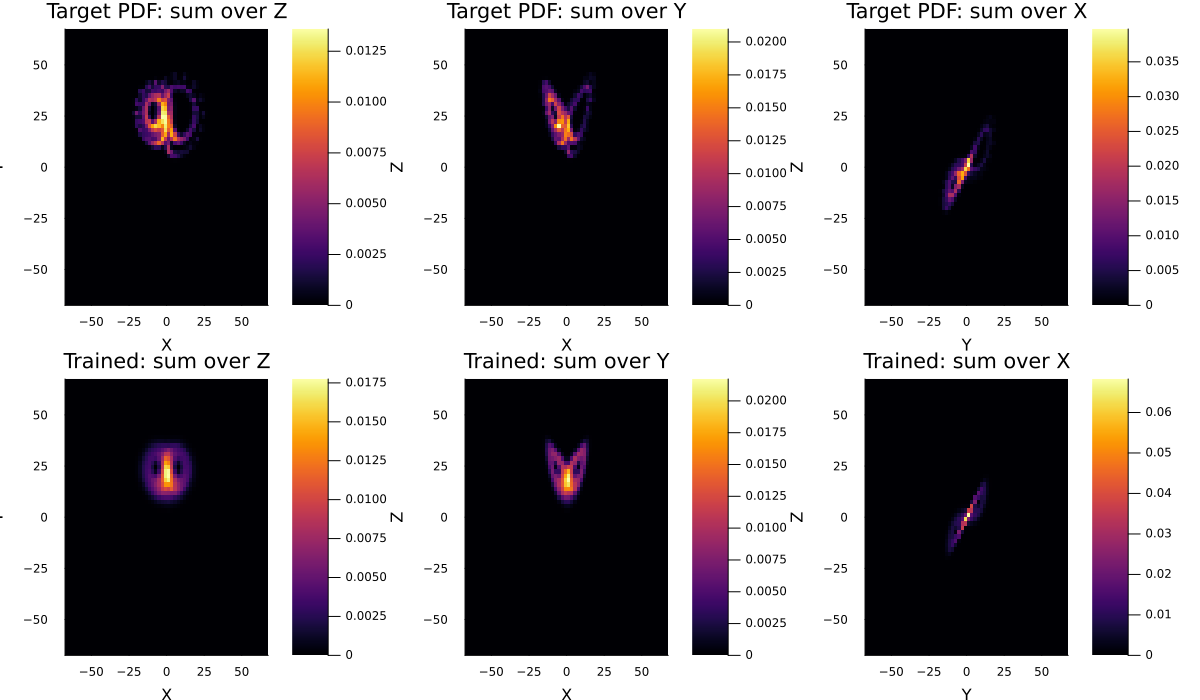

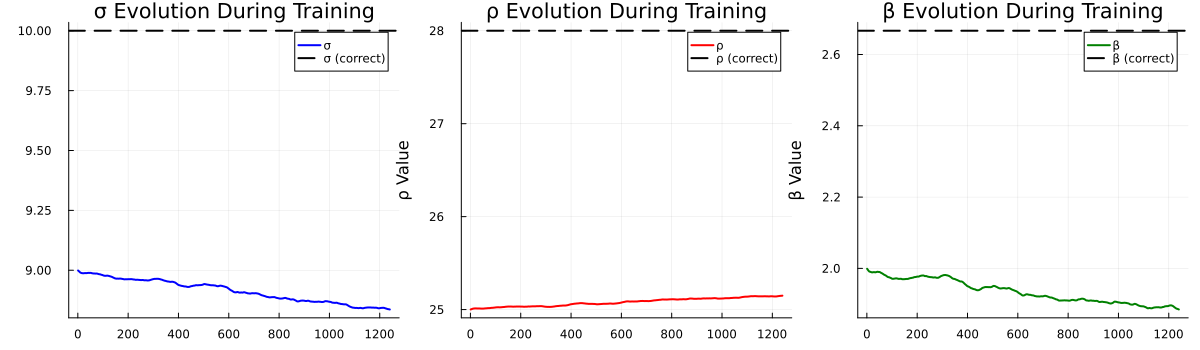

In [14]:
recovered_pdf = res_test.final_statistics[:pdf3d]
m = length(recovered_pdf.centers)
pdf = reshape(recovered_pdf.p3d, m, m, m)

# Sum along each axis to get 2D marginals for recovered PDF
marg_xy_rec = sum(pdf, dims=3)[:, :, 1]  # sum over z
marg_xz_rec = sum(pdf, dims=2)[:, 1, :]  # sum over y
marg_yz_rec = sum(pdf, dims=1)[1, :, :]  # sum over x

plt_xy_rec = Plots.heatmap(recovered_pdf.centers, recovered_pdf.centers, marg_xy_rec; xlabel="X", ylabel="Y", title="Trained: sum over Z")
plt_xz_rec = Plots.heatmap(recovered_pdf.centers, recovered_pdf.centers, marg_xz_rec; xlabel="X", ylabel="Z", title="Trained: sum over Y")
plt_yz_rec = Plots.heatmap(recovered_pdf.centers, recovered_pdf.centers, marg_yz_rec; xlabel="Y", ylabel="Z", title="Trained: sum over X")
plt_marginals_rec = Plots.plot(plt_xy_rec, plt_xz_rec, plt_yz_rec; layout=(1,3), size=(1200,350))

# Initial PDF marginals (already computed aboe)
plt_marginals_init = plt_marginals

# Stack initial and recovered marginals vertically
plt_compare = Plots.plot(plt_marginals_init, plt_marginals_rec; layout=(2,1), size=(1200,700))
display(plt_compare)

plot_params = plot_param_history(res_test, base_params_test)
display(plot_params)

# Understanding loss landscape

In [ ]:
###############################
# Loss landscape vs ρ (no deps)
###############################
# Requires in scope:
#   L63Parameters, classic_params, integrate,
#   soft_hist_3d_local, hard_hist_3d

# --- lightweight losses (vector-on-vector) ---
@inline function _ce_vec(p::AbstractVector{T}, q::AbstractVector{T}) where {T}
    ϵ = T(1e-12); s = zero(T)
    @inbounds for i in eachindex(p,q)
        s += -p[i]*log(q[i] + ϵ)
    end
    s
end

@inline function _kl_vec(p::AbstractVector{T}, q::AbstractVector{T}) where {T}
    ϵ = T(1e-12); s = zero(T)
    @inbounds for i in eachindex(p,q)
        pi = max(p[i], ϵ); qi = max(q[i], ϵ)
        s += pi*(log(pi) - log(qi))
    end
    s
end


@inline function soft_hist_3d_local(xs::AbstractVector{T}, ys::AbstractVector{T}, zs::AbstractVector{T},
                                         centers::AbstractVector{T}, h::T, out::AbstractVector{T};
                                         R::Int = 3) where {T}
    @assert length(out) == length(centers)^3
    fill!(out, zero(T))

    m      = length(centers)
    Δ      = (centers[end] - centers[1]) / (m - 1)
    invΔ   = one(T) / Δ
    inv2h2 = one(T) / (2*h*h)
    him1   = m - 1
    @inbounds @fastmath for s in eachindex(xs)
        # map sample -> nearest center indices (clamped)
        posx = (xs[s] - centers[1]) * invΔ; posx = isfinite(posx) ? clamp(posx, zero(T), T(him1)) : (posx > zero(T) ? T(him1) : zero(T))
        posy = (ys[s] - centers[1]) * invΔ; posy = isfinite(posy) ? clamp(posy, zero(T), T(him1)) : (posy > zero(T) ? T(him1) : zero(T))
        posz = (zs[s] - centers[1]) * invΔ; posz = isfinite(posz) ? clamp(posz, zero(T), T(him1)) : (posz > zero(T) ? T(him1) : zero(T))
        ix0  = Int(round(posx)) + 1
        iy0  = Int(round(posy)) + 1
        iz0  = Int(round(posz)) + 1

        iL = max(1, ix0 - R); iH = min(m, ix0 + R)
        jL = max(1, iy0 - R); jH = min(m, iy0 + R)
        kL = max(1, iz0 - R); kH = min(m, iz0 + R)

        # 1-D Gaussian weights (separable kernel) → only O(R) exp calls per axis, instead of O(R^3)
        ex = Vector{T}(undef, iH - iL + 1)
        ey = Vector{T}(undef, jH - jL + 1)
        ez = Vector{T}(undef, kH - kL + 1)
        @inbounds @fastmath for i in eachindex(ex);  dx = xs[s] - centers[iL + i - 1];  ex[i] = exp(-(dx*dx) * inv2h2); end
        @inbounds @fastmath for j in eachindex(ey);  dy = ys[s] - centers[jL + j - 1];  ey[j] = exp(-(dy*dy) * inv2h2); end
        @inbounds @fastmath for k in eachindex(ez);  dz = zs[s] - centers[kL + k - 1];  ez[k] = exp(-(dz*dz) * inv2h2); end

        # accumulate outer products ex ⊗ ey ⊗ ez into the flattened 3-D block
        @inbounds @simd for ii in 0:(length(ex)-1)
            base_i = (iL + ii - 1) * m * m
            wi = ex[ii+1]
            @simd for jj in 0:(length(ey)-1)
                base_ij = base_i + (jL + jj - 1) * m
                wij = wi * ey[jj+1]
                @simd for kk in 0:(length(ez)-1)
                    out[base_ij + (kL + kk)] += wij * ez[kk+1]
                end
            end
        end
    end
    # normalize
    s = sum(out)
    if s > eps(T); @inbounds out ./= s
    else;          @inbounds fill!(out, one(T)/length(out))
    end
    return nothing
end


# --- helper: build a 3D pdf with burn-in + subsampling, pooled across all ICs ---
function _build_pdf_for(params::L63Parameters, U0::AbstractMatrix,
                        T_total::Real, steps::Int;
                        burn_frac::Real=0.6, stride::Int=3,
                        centers::AbstractVector, h::Real, R::Int,
                        hard_hist::Bool=false)
    dt = T_total / steps
    tspan = (0.0, T_total)
    m = length(centers)
    p3d = zeros(eltype(centers), m^3)

    # accumulate samples from all ICs
    for b in 1:size(U0,2)
        sol = integrate(params, @view(U0[:,b]), tspan, dt)
        U = sol.u
        n = size(U,1)
        start = max(2, floor(Int, 1 + burn_frac*n))
        idx = start:stride:n
        xs = U[idx,1]; ys = U[idx,2]; zs = U[idx,3]

        # accumulate once per IC (normalize at the end globally)
        tmp = zeros(eltype(centers), m^3)
        if hard_hist
            # hard histogram needs no h/R
            hard_hist_3d(xs, ys, zs, centers, tmp)
        else
            soft_hist_3d_local(xs, ys, zs, centers, h, tmp; R=R)
        end
        @. p3d += tmp
    end

    s = sum(p3d)
    s > 0 ? (@. p3d = p3d / s) : fill!(p3d, 1/length(p3d))
    return p3d
end

# pick centers (& Δ) from a target trajectory span and a margin
function _make_centers_from_traj(U::AbstractMatrix, nbins::Int; margin::Real=1.5)
    hw = maximum(abs, vcat(U[:,1], U[:,2], U[:,3])) * margin
    centers = collect(range(-hw, hw; length=nbins))
    Δ = (centers[end] - centers[1])/(nbins-1)
    return centers, Δ
end

"""
loss_curve_rho(; kwargs...) -> (rho_vals, losses[, plt])

Compute L(ρ) against a target PDF (from `classic_params()`) using the SAME
hyperparameters you choose for the sweep.
"""
function loss_curve_rho(; rho_grid = 22.0:0.5:32.0,
    fixed_sigma::Real = 10.0, fixed_beta::Real = 8/3,
    T_total::Real = 60.0, steps::Int = 2400,
    burn_frac::Real = 0.6, stride::Int = 3,
    nbins::Int = 24, h_mult::Real = 1.5, margin::Real = 1.5,
    U0 = [1.0, 1.0, 25.0],         # 3-vector or 3×B matrix
    loss_mode::Symbol = :cross_entropy,
    make_plot::Bool = true,
    hard_hist::Bool = false)

    # ensure U0 is a 3×B matrix
    U0mat = (ndims(U0) == 1) ? reshape(Float64.(U0), 3, 1) : Float64.(U0)

    # 1) TARGET pdf using classic_params() under the SAME hyperparams
    dt = T_total / steps
    sol_tgt = integrate(classic_params(), @view(U0mat[:,1]), (0.0, T_total), dt)
    centers, Δ = _make_centers_from_traj(sol_tgt.u, nbins; margin=margin)
    h = h_mult * Δ
    R = max(1, ceil(Int, 3h/Δ))

    target_pdf = _build_pdf_for(classic_params(), U0mat, T_total, steps;
                                burn_frac=burn_frac, stride=stride,
                                centers=centers, h=h, R=R, hard_hist=hard_hist)

    # 2) Evaluate loss for each ρ on same grid/bandwidth
    vals = collect(rho_grid)
    losses = Vector{Float64}(undef, length(vals))

    loss_fun = loss_mode === :cross_entropy ? _ce_vec :
               loss_mode === :kl            ? _kl_vec :
               error("loss_mode must be :cross_entropy or :kl")

    for (i, ρ) in enumerate(vals)
        p = L63Parameters(fixed_sigma, ρ, fixed_beta, 0, 0, 0, 1)
        p3d = _build_pdf_for(p, U0mat, T_total, steps;
                             burn_frac=burn_frac, stride=stride,
                             centers=centers, h=h, R=R, hard_hist=hard_hist)
        losses[i] = loss_fun(target_pdf, p3d)
    end

    if make_plot
        # caller must have `using Plots` in scope
        plt = Plots.plot(vals, losses; xlabel="ρ", ylabel="Loss",
                         title="Loss vs ρ ($(String(loss_mode)))",
                         legend=false, linewidth=2)
        return vals, losses, plt
    else
        return vals, losses
    end
end

ErrorException: invalid method definition in Main: function LorenzParameterEstimation.soft_hist_3d_local must be explicitly imported to be extended

In [6]:
# Change parameters here once to affect both sweeps
common = (
    rho_grid = 20.0:0.25:30.0,
    fixed_sigma = 10.0,
    fixed_beta = 8/3,
    T_total = 600.0,
    steps = 50000,
    burn_frac = 0,
    stride = 2,
    nbins = 32,
    h_mult = 0.2,
    margin = 1.4,
    loss_mode = :kl,
    make_plot = true,
)

ρ_vals1, losses1, plt1 = loss_curve_rho(; common..., hard_hist = true)
ρ_vals2, losses2, plt2 = loss_curve_rho(; common..., hard_hist = false)

# display the two loss curves side-by-side
# create a top title row and place the two plots below it
l = @layout [a{0.08h}; [b c]]
plt_title = Plots.plot(legend=false, grid=false, framestyle=:none,
                 title="Loss Landscape vs ρ: Hard vs Soft Histograms",
                 xticks=false, yticks=false)
plt_compare = Plots.plot(plt_title, plt1, plt2; layout=l, size=(1200,400))
display(plt_compare)


UndefVarError: UndefVarError: `loss_curve_rho` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

# Trying out above tested loss landscape

In [ ]:
# ---------- helpers ----------
"""
Estimate symmetric support halfwidth (range of grid) from solution samples.
method = :percentile (p in (0,1)) or :max.
"""
function estimate_halfwidth(sol; burn_frac=0.1, stride=2, method=:percentile, p=0.995, margin=1.2)
    start_idx = max(2, floor(Int, 1 + burn_frac*size(sol.u,1)))
    idx = start_idx:stride:size(sol.u,1)
    @assert !isempty(idx) "idx is empty"
    X = reduce(hcat, (view(sol.u, i, :) for i in idx))
    mask = [all(isfinite, col) for col in eachcol(X)]
    X = X[:, mask]
    @assert !isempty(X) "all samples non-finite"
    if method === :percentile
        lo = quantile(vec(abs.(X)), 1 - p)  # not used directly; keep symmetric
        hw = quantile(vec(abs.(X)), p) * margin
    else
        hw = maximum(abs, X) * margin
    end
    return float(hw)
end

"""
Build normalized soft 3D target PDF with label smoothing.
"""
function make_target_pdf(x, y, z, centers; h_mult=0.6, α=1e-3, R=nothing)
    Δ = (centers[end]-centers[1])/(length(centers)-1)
    h = h_mult * Δ
    R === nothing && (R = max(1, ceil(Int, 4h/Δ)))
    p3d = zeros(Float64, length(centers)^3)
    soft_hist_3d_local(x, y, z, centers, h, p3d; R=R)
    s = sum(p3d); @assert s > 0 "hist sum zero"
    p3d ./= s
    p3d .= (1-α) .* p3d .+ α/length(p3d)
    return (centers=centers, p3d=p3d), h
end

In [4]:
# ---------- choose consistent knobs ----------
nbins      = 96
burn_frac  = 0.0
stride     = 2
loss_mode  = :cross_entropy  # use :kl if you prefer
h_mult     = 0.6             # bandwidth = h_mult * Δ

# ---------- dynamics + ICs ----------
fixed_σ = 10.0
fixed_β = 8/3
target_params = L63Parameters(σ=fixed_σ, ρ=28.0, β=fixed_β)
T_total = 600.0
steps_long = 50000
dt_long = T_total / steps_long
rng = MersenneTwister(1234)
ics_test = [[1.0, 1.0, 25.0] .+ 0.20 .* randn(rng, 3) for _ in 1:256]
U0  = hcat(ics_test...)

sol_tgt = integrate(target_params, @view(U0[:,1]), (0.0, T_total), dt_long)


# ---------- compute halfwidth (don’t guess) ----------
halfwidth = estimate_halfwidth(sol_tgt; burn_frac=burn_frac, stride=stride,
                               method=:percentile, p=0.995, margin=1.10)

# ---------- centers via make_pdf_config (single source of truth) ----------
pdf_cfg = make_pdf_config(Float64;
    nbins=nbins,
    range_halfwidth=halfwidth,
    bandwidth=nothing,     # let make_pdf_config set h = 0.5Δ; we’ll override below
    loss_mode=loss_mode,
)

# override bandwidth to h_mult*Δ (optional, keeps one place for h_mult)
Δ = (pdf_cfg.centers[end]-pdf_cfg.centers[1])/(length(pdf_cfg.centers)-1)
pdf_cfg = PdfConfig{Float64}(pdf_cfg.centers, h_mult*Δ, pdf_cfg.loss_mode)


# ---------- select + clamp samples ----------
start_idx = max(2, floor(Int, 1 + burn_frac*size(sol_tgt.u,1)))
idx = start_idx:stride:size(sol_tgt.u,1)
x = @view sol_tgt.u[idx, 1]
y = @view sol_tgt.u[idx, 2]
z = @view sol_tgt.u[idx, 3]
mask = isfinite.(x) .& isfinite.(y) .& isfinite.(z)
x = x[mask]; y = y[mask]; z = z[mask]
lo, hi = first(pdf_cfg.centers), last(pdf_cfg.centers)
clamp!(x, lo, hi); clamp!(y, lo, hi); clamp!(z, lo, hi)

# ---------- target PDF (uses the same centers/bandwidth logic) ----------
target_pdf, _h = make_target_pdf(x, y, z, pdf_cfg.centers; h_mult=h_mult, α=1e-3)

# ---------- neutral schedule ----------
sched = PdfSchedule{Float64}(1.0, 1.0, 1)

# ---------- climate config ----------
cfg = ClimateConfig(
    dt = dt_long,
    steps = steps_long,
    samples_per_epoch = 1000,
    initial_conditions = U0,
    pdf = pdf_cfg,
    schedule = sched,
    rng = rng,
    batch_size = 16,
)

# ---------- train: update only ρ ----------
init_params = L63Parameters(σ=fixed_σ, ρ=25.0, β=fixed_β)

res = train_statistics(
    init_params;
    target = target_pdf,
    stats = (:pdf3d,),
    optimizer = Optimisers.Adam(1e-3),
    update_mask = (σ=false, ρ=true, β=false, x_s=false, y_s=false, z_s=false, θ=false),
    epochs = 10_000,
    refresh = 10,
    early_stopping_patience = 1_500,
    early_stopping_min_delta = 1e-6,
    rel_delta = 1e-5,
    cfg = cfg,
    verbose = true,
    gradient_verbose = false,
    gradient_clip_norm = 5.0,
)

println("Init: $(init_params)\nRecovered: $(res.params)\nTarget: $(target_params)")

plot(res.loss_history; xlabel="Epoch", ylabel="PDF Loss",
     title="PDF Training Loss ($(String(loss_mode)))", legend=false)


MethodError: MethodError: no method matching PdfConfig{Float64}(::Vector{Float64}, ::Float64, ::Symbol)
The type `PdfConfig{Float64}` exists, but no method is defined for this combination of argument types when trying to construct it.

Closest candidates are:
  (::Type{PdfConfig{T}} where T)(::Any, ::Any, ::Any, !Matched::Any, !Matched::Any)
   @ LorenzParameterEstimation ~/master_thesis/LorenzParameterEstimation/src/training_climate.jl:77
  PdfConfig{T}(; centers, bandwidth, loss_mode, sinkhorn_ε, sinkhorn_iters) where T
   @ LorenzParameterEstimation ~/master_thesis/LorenzParameterEstimation/src/training_climate.jl:76


In [ ]:
# ---------- loss landscape (hard vs soft) re-using same halfwidth ----------
common = (
    rho_grid = 20.0:0.25:30.0,
    fixed_sigma = 10.0,
    fixed_beta = 8/3,
    T_total = 600.0,
    steps = 50000,
    burn_frac = burn_frac,
    stride = stride,
    nbins = nbins,
    range_halfwidth = halfwidth,   # <<< same as above
    h_mult = 0.6,
    margin = 1.0,
    loss_mode = :kl,
    make_plot = true,
)

ρ_vals1, losses1, plt1 = loss_curve_rho(; common..., hard_hist=true)
ρ_vals2, losses2, plt2 = loss_curve_rho(; common..., hard_hist=false)

l = @layout [a{0.08h}; [b c]]
plt_title = plot(legend=false, grid=false, framestyle=:none,
                 title="Loss vs ρ: Hard vs Soft", xticks=false, yticks=false)
plt_compare = plot(plt_title, plt1, plt2; layout=l, size=(1200,400))
display(plt_compare)